In this exercise, you'll redo the data gathering phase of the UNData Exploration project by using APIs instead of downloading csv files.

You'll make use of the World Bank Indicators API. Note that this API does not require an API key. Before attempting the exercise, it would be a good idea to skim through the Documentation page and to check out the Basic Call Structure article.

1. Use the API to get all available data for the GDP per capita, PPP (constant 2017 international $) indicator. Hint: this indicator has code "NY.GDP.PCAP.PP.KD". Adjust the query parameters so that you can retrieve all available rows. Convert the results to a DataFrame.

In [2]:
import requests
import pandas as pd

# Indicator
indicator = "NY.GDP.PCAP.PP.KD"

# Base URL
url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"

# Parameters
params = {
    "format": "json",
    "per_page": 20000,
    "page": 1
}

all_data = []

while True:
    response = requests.get(url, params=params)
    data = response.json()

    # First element = metadata, second = actual data
    if len(data) < 2:
        break

    page_data = data[1]
    all_data.extend(page_data)

    # Check if more pages exist
    total_pages = data[0]['pages']
    if params["page"] >= total_pages:
        break

    params["page"] += 1

# Convert to DataFrame
df = pd.DataFrame(all_data)

# Select useful columns
df = df[[
    'countryiso3code',
    'country',
    'date',
    'value'
]]

# Clean nested country column
df['country'] = df['country'].apply(lambda x: x['value'])

# Rename columns
df.columns = ['country_code', 'country', 'year', 'gdp_per_capita_ppp']

# Drop missing values
df = df.dropna(subset=['gdp_per_capita_ppp'])

# Convert types
df['year'] = df['year'].astype(int)
df['gdp_per_capita_ppp'] = df['gdp_per_capita_ppp'].astype(float)

df.head()

,country_code,country,year,gdp_per_capita_ppp
1,AFE,Africa Eastern and Southern,2024,4106.434140
2,AFE,Africa Eastern and Southern,2023,4083.993003
3,AFE,Africa Eastern and Southern,2022,4106.501907
4,AFE,Africa Eastern and Southern,2021,4056.113017
5,AFE,Africa Eastern and Southern,2020,3978.931395


In [3]:
df.to_csv("gdp_per_capita_ppp.csv", index=False)

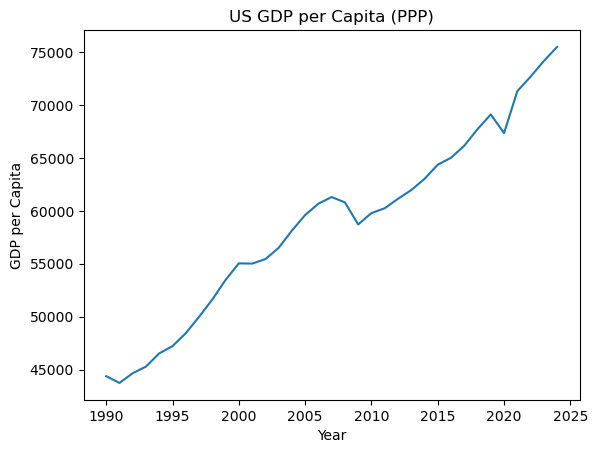

In [4]:
import matplotlib.pyplot as plt

df_us = df[df['country'] == 'United States']

plt.plot(df_us['year'], df_us['gdp_per_capita_ppp'])
plt.title("US GDP per Capita (PPP)")
plt.xlabel("Year")
plt.ylabel("GDP per Capita")
plt.show()

2. Now, use the API to get all available data for Life expectancy at birth, total (years). This indicator has code "SP.DYN.LE00.IN". Again, convert the results to a DataFrame.

In [6]:
import requests
import pandas as pd

def fetch_world_bank_data(indicator_code):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    
    params = {
        "format": "json",
        "per_page": 20000,
        "page": 1
    }
    
    all_data = []
    
    while True:
        response = requests.get(url, params=params)
        data = response.json()
        
        # Break if no data
        if len(data) < 2:
            break
        
        all_data.extend(data[1])
        
        total_pages = data[0]['pages']
        if params["page"] >= total_pages:
            break
        
        params["page"] += 1

    return pd.DataFrame(all_data)

# Fetch life expectancy data
df_life = fetch_world_bank_data("SP.DYN.LE00.IN")

# Keep relevant columns
df_life = df_life[[
    'countryiso3code',
    'country',
    'date',
    'value'
]]

# Clean nested country column
df_life['country'] = df_life['country'].apply(lambda x: x['value'])

# Rename columns
df_life.columns = ['country_code', 'country', 'year', 'life_expectancy']

# Drop missing values
df_life = df_life.dropna(subset=['life_expectancy'])

# Convert types
df_life['year'] = df_life['year'].astype(int)
df_life['life_expectancy'] = df_life['life_expectancy'].astype(float)

df_life.head()

,country_code,country,year,life_expectancy
1,AFE,Africa Eastern and Southern,2024,65.349930
2,AFE,Africa Eastern and Southern,2023,65.146228
3,AFE,Africa Eastern and Southern,2022,64.487152
4,AFE,Africa Eastern and Southern,2021,62.979999
5,AFE,Africa Eastern and Southern,2020,63.766484


In [7]:
df_gdp = df              # your GDP dataset
df_life = df_life        # life expectancy dataset

df_merged = pd.merge(
    df_gdp,
    df_life,
    on=['country_code', 'country', 'year'],
    how='inner'
)

In [9]:
df_merged[['gdp_per_capita_ppp', 'life_expectancy']].corr()

,gdp_per_capita_ppp,life_expectancy
gdp_per_capita_ppp,1.000000,0.666904
life_expectancy,0.666904,1.000000


The correlation between GDP per capita (PPP) and life expectancy is approximately 0.67, indicating a moderately strong positive relationship. This suggests that countries with higher economic output per person tend to have higher life expectancy, although other factors also influence this relationship.

3. Merge the two results DataFrames together. You may want to rename or drop columns prior to merging.

In [12]:
df_gdp = df[['country_code', 'country', 'year', 'gdp_per_capita_ppp']]

In [13]:
df_life = df_life[['country_code', 'country', 'year', 'life_expectancy']]

In [14]:
df_merged = pd.merge(
    df_gdp,
    df_life,
    on=['country_code', 'country', 'year'],
    how='inner'
)

In [15]:
df_merged.head()

,country_code,country,year,gdp_per_capita_ppp,life_expectancy
0,AFE,Africa Eastern and Southern,2024,4106.434140,65.349930
1,AFE,Africa Eastern and Southern,2023,4083.993003,65.146228
2,AFE,Africa Eastern and Southern,2022,4106.501907,64.487152
3,AFE,Africa Eastern and Southern,2021,4056.113017,62.979999
4,AFE,Africa Eastern and Southern,2020,3978.931395,63.766484


4. You can also get more information about the available countries (region, capital city, income level classification, etc.) by using the Country API. Use this API to pull in all available data. Merge this with your other datasets. Use this to now remove the rows that correspond to regions and not countries.

In [16]:
import requests
import pandas as pd

url = "https://api.worldbank.org/v2/country"
params = {
    "format": "json",
    "per_page": 300
}

response = requests.get(url, params=params)
data = response.json()

In [17]:
countries = pd.DataFrame(data[1])

In [18]:
df_countries = countries[[
    "id",
    "name",
    "region",
    "incomeLevel",
    "capitalCity"
]]

In [19]:
df_countries["region"] = df_countries["region"].apply(lambda x: x["value"])
df_countries["incomeLevel"] = df_countries["incomeLevel"].apply(lambda x: x["value"])

C:\Users\Student\AppData\Local\Temp\ipykernel_3828\719649477.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_countries["region"] = df_countries["region"].apply(lambda x: x["value"])
C:\Users\Student\AppData\Local\Temp\ipykernel_3828\719649477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_countries["incomeLevel"] = df_countries["incomeLevel"].apply(lambda x: x["value"])


In [20]:
df_merged

,country_code,country,year,gdp_per_capita_ppp,life_expectancy
0,AFE,Africa Eastern and Southern,2024,4106.434140,65.349930
1,AFE,Africa Eastern and Southern,2023,4083.993003,65.146228
2,AFE,Africa Eastern and Southern,2022,4106.501907,64.487152
3,AFE,Africa Eastern and Southern,2021,4056.113017,62.979999
4,AFE,Africa Eastern and Southern,2020,3978.931395,63.766484
...,...,...,...,...,...
8460,ZWE,Zimbabwe,1994,6010.742417,52.537000
8461,ZWE,Zimbabwe,1993,5509.083113,53.976000
8462,ZWE,Zimbabwe,1992,5532.037403,55.602000
8463,ZWE,Zimbabwe,1991,6254.274735,57.037000


In [21]:
df_final = pd.merge(
    df_merged,
    df_countries,
    left_on="country_code",
    right_on="id",
    how="left"
)

In [24]:
df_final = df_final[df_final["region"] != "Aggregates"]

In [25]:
df_final.head()
df_final.shape

(6925, 10)

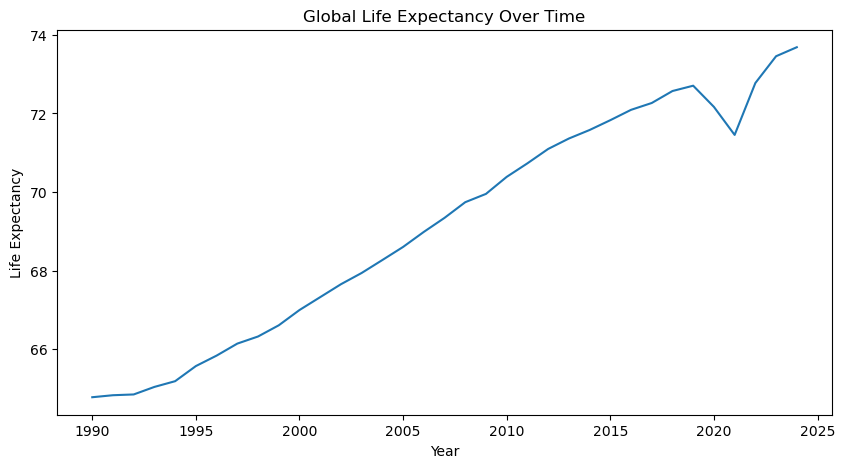

In [26]:
df_time = df_final.groupby("year")["life_expectancy"].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(df_time["year"], df_time["life_expectancy"])

plt.title("Global Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")

plt.show()

Bonus Questions: After doing a basic request to get all records, you can attempt these exercises to get additional practice using query parameters.

1. Adjust your request so that it returns data just for the United States.

In [29]:
import requests
import pandas as pd

indicator = "SP.DYN.LE00.IN"  # life expectancy (you can swap if needed)

url = f"https://api.worldbank.org/v2/country/USA/indicator/{indicator}"

params = {
    "format": "json",
    "per_page": 20000
}

response = requests.get(url, params=params)
data = response.json()

df_us = pd.DataFrame(data[1])

df_us.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2025,NaN,,,0
1,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2024,78.890244,,,0
2,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2023,78.385366,,,0
3,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2022,77.434146,,,0
4,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2021,76.329268,,,0


In [30]:
df_us = df_us[['country', 'date', 'value']]

df_us['country'] = df_us['country'].apply(lambda x: x['value'])

df_us.columns = ['country', 'year', 'life_expectancy']

df_us['year'] = df_us['year'].astype(int)
df_us['life_expectancy'] = df_us['life_expectancy'].astype(float)

df_us.head()

,country,year,life_expectancy
0,United States,2025,NaN
1,United States,2024,78.890244
2,United States,2023,78.385366
3,United States,2022,77.434146
4,United States,2021,76.329268


2. Adjust your request so that it returns data just for the United States for the year 2021.

In [31]:
import requests
import pandas as pd

indicator = "SP.DYN.LE00.IN"

url = f"https://api.worldbank.org/v2/country/USA/indicator/{indicator}"

params = {
    "format": "json",
    "per_page": 20000,
    "date": "2021"
}

response = requests.get(url, params=params)
data = response.json()

df_us_2021 = pd.DataFrame(data[1])

df_us_2021.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2021,76.329268,,,0


In [32]:
df_us_2021 = df_us_2021[['country', 'date', 'value']]

df_us_2021['country'] = df_us_2021['country'].apply(lambda x: x['value'])

df_us_2021.columns = ['country', 'year', 'life_expectancy']

df_us_2021['year'] = df_us_2021['year'].astype(int)
df_us_2021['life_expectancy'] = df_us_2021['life_expectancy'].astype(float)

df_us_2021

,country,year,life_expectancy
0,United States,2021,76.329268


3. Adjust your request so that it returns data just for the United States for the years 2000 through 2021.

In [33]:
import requests
import pandas as pd

indicator = "SP.DYN.LE00.IN"

url = f"https://api.worldbank.org/v2/country/USA/indicator/{indicator}"

params = {
    "format": "json",
    "per_page": 20000,
    "date": "2000:2021"
}

response = requests.get(url, params=params)
data = response.json()

df_us = pd.DataFrame(data[1])

df_us.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2021,76.329268,,,0
1,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2020,76.980488,,,0
2,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2019,78.787805,,,0
3,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2018,78.639024,,,0
4,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2017,78.539024,,,0


In [34]:
df_us = df_us[['country', 'date', 'value']]

df_us['country'] = df_us['country'].apply(lambda x: x['value'])

df_us.columns = ['country', 'year', 'life_expectancy']

df_us['year'] = df_us['year'].astype(int)
df_us['life_expectancy'] = df_us['life_expectancy'].astype(float)

df_us.sort_values('year').head()

,country,year,life_expectancy
21,United States,2000,76.636585
20,United States,2001,76.836585
19,United States,2002,76.936585
18,United States,2003,77.036585
17,United States,2004,77.487805


4. Adjust your request so that it returns data for the United States and Canada for the years 2000 through 2021.

In [35]:
import requests
import pandas as pd

indicator = "SP.DYN.LE00.IN"

url = f"https://api.worldbank.org/v2/country/USA;CAN/indicator/{indicator}"

params = {
    "format": "json",
    "per_page": 20000,
    "date": "2000:2021"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data[1])

df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'CA', 'value': 'Canada'}",CAN,2021,81.451463,,,0
1,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'CA', 'value': 'Canada'}",CAN,2020,81.530000,,,0
2,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'CA', 'value': 'Canada'}",CAN,2019,82.158537,,,0
3,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'CA', 'value': 'Canada'}",CAN,2018,81.803659,,,0
4,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'CA', 'value': 'Canada'}",CAN,2017,81.807805,,,0


In [36]:
df = df[['country', 'date', 'value']]

df['country'] = df['country'].apply(lambda x: x['value'])

df.columns = ['country', 'year', 'life_expectancy']

df['year'] = df['year'].astype(int)
df['life_expectancy'] = df['life_expectancy'].astype(float)

df.sort_values(['country', 'year']).head()

,country,year,life_expectancy
21,Canada,2000,79.166829
20,Canada,2001,79.398049
19,Canada,2002,79.530732
18,Canada,2003,79.715122
17,Canada,2004,79.992195


In [37]:
df_sorted = df.sort_values(['country', 'year'])

In [38]:
from IPython.display import display

display(df_sorted)

,country,year,life_expectancy
21,Canada,2000,79.166829
20,Canada,2001,79.398049
19,Canada,2002,79.530732
18,Canada,2003,79.715122
17,Canada,2004,79.992195
16,Canada,2005,80.112683
15,Canada,2006,80.543659
14,Canada,2007,80.543659
13,Canada,2008,80.724634
12,Canada,2009,81.066098


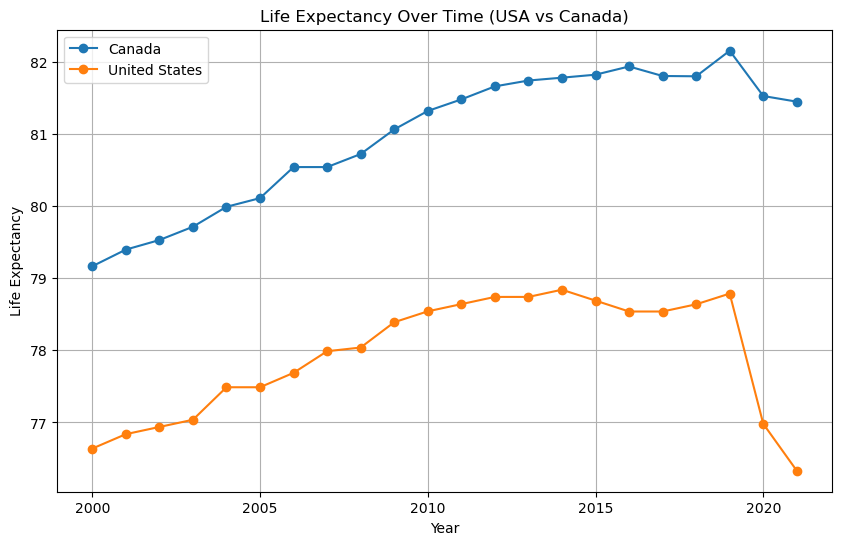

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for country in df['country'].unique():
    subset = df[df['country'] == country]
    plt.plot(subset['year'], subset['life_expectancy'], marker='o', label=country)

plt.title("Life Expectancy Over Time (USA vs Canada)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)

plt.show()

5. If you haven't already done so and you would like to get some additional practice using loops, use the page parameter in order to pull all records. Do not change the value of the per_page parameter. You will likely need to utilize a loop of some kind in order to pull all records.

In [42]:
import requests
import pandas as pd

indicator = "SP.DYN.LE00.IN"

url = f"https://api.worldbank.org/v2/country/USA/indicator/{indicator}"

params = {
    "format": "json",
    "per_page": 50,   # DO NOT increase to huge number
    "page": 1
}

all_data = []

while True:
    response = requests.get(url, params=params)
    data = response.json()

    # actual data is in index 1
    page_data = data[1]
    all_data.extend(page_data)

    # total pages from metadata
    total_pages = data[0]["pages"]

    if params["page"] >= total_pages:
        break

    params["page"] += 1


df = pd.DataFrame(all_data)
df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2025,NaN,,,0
1,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2024,78.890244,,,0
2,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2023,78.385366,,,0
3,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2022,77.434146,,,0
4,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'US', 'value': 'United States'}",USA,2021,76.329268,,,0


In [43]:
df = df[['country', 'date', 'value']]

df['country'] = df['country'].apply(lambda x: x['value'])

df.columns = ['country', 'year', 'life_expectancy']

df['year'] = df['year'].astype(int)
df['life_expectancy'] = df['life_expectancy'].astype(float)

df.sort_values('year').head()

,country,year,life_expectancy
65,United States,1960,69.770732
64,United States,1961,70.270732
63,United States,1962,70.119512
62,United States,1963,69.917073
61,United States,1964,70.165854


6. The endpoint "http://api.worldbank.org/v2/indicator" will return information about all available indicators. See Indicator API Queries. Use this endpoint to find the code for the "Public Expenditure on Education (% GDP)" indicator.

In [49]:
import requests

url = "http://api.worldbank.org/v2/indicator"
params = {
    "format": "json",
    "per_page": 20000,
    "page": 1
}

response = requests.get(url, params=params)
data = response.json()

indicators = data[1]

for ind in indicators:
    if ind['name'] and "education" in ind['name'].lower():
        print(ind['id'], ind['name'])

3.1_LOW.SEC.NEW.TEACHERS Lower secondary education, new teachers, national source
3.1_PRI.NEW.ENTRANTS Primary education, new entrants, national source
3.11_LOW.SEC.CLASSROOMS Lower secondary education, classrooms, national source
3.12_LOW.SEC.NEW.CLASSROOMS Lower secondary education, new classrooms, national source
3.13_PRI.MATH.BOOK.PER.PUPIL Ratio of textbooks per pupil, primary education, mathematics
3.14_PRI.LANGU.BOOK.PER.PUPIL Ratio of textbooks per pupil, primary education, language
3.2_PRI.STUDENTS Primary education, pupils, national source
3.3_PRI.TEACHERS Primary education, teachers, national source
3.4_PRI.NEW.TEACHERS Primary education, new teachers, national source
3.5_PRI.CLASSROOMS Primary education, classrooms, national source
3.6_PRI.NEW.CLASSROOMS Primary education, new classrooms, national source
3.7_LOW.SEC.NEW.ENTRANTS Lower Secondary education, new entrants, national source
3.8_LOW.SEC.STUDENTS Lower secondary education, pupils, national source
3.9_LOW.SEC.TEACHE

In [50]:
import requests
import pandas as pd

url = "http://api.worldbank.org/v2/indicator"
params = {
    "format": "json",
    "per_page": 20000,
    "page": 1
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data[1])

In [51]:
df["name"] = df["name"].str.lower()

In [52]:
df[df["name"].str.contains("education")]

,id,name,unit,source,sourceNote,sourceOrganization,topics
190,3.1_LOW.SEC.NEW.TEACHERS,"lower secondary education, new teachers, natio...",,"{'id': '34', 'value': 'Global Partnership for ...",Persons employed for the first time in an offi...,Data were collected from national and other pu...,[]
191,3.1_PRI.NEW.ENTRANTS,"primary education, new entrants, national source",,"{'id': '34', 'value': 'Global Partnership for ...",Pupils entering primary school for the first t...,Data were collected from national and other pu...,[]
193,3.11_LOW.SEC.CLASSROOMS,"lower secondary education, classrooms, nationa...",,"{'id': '34', 'value': 'Global Partnership for ...","Number of rooms or single accommodations, mini...",Data were collected from national and other pu...,[]
194,3.12_LOW.SEC.NEW.CLASSROOMS,"lower secondary education, new classrooms, nat...",,"{'id': '34', 'value': 'Global Partnership for ...","Number of rooms or single accommodations, mini...",Data were collected from national and other pu...,[]
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"ratio of textbooks per pupil, primary educatio...",,"{'id': '34', 'value': 'Global Partnership for ...",Number of books used by a single pupil used as...,Data were collected from national and other pu...,[]
...,...,...,...,...,...,...,...
17333,PER.VOC.TNR,"world bank: teaching/non-teaching staff ratio,...",,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17334,PER.VOC.TOT,world bank: share of total education expenditu...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17335,PER.VOC.TOT.CPL,world bank: capital share of total education e...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17336,PER.VOC.TOTEXP,world bank: total expenditures on technical vo...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]


In [53]:
df[df["name"].str.contains("government expenditure on education")]

,id,name,unit,source,sourceNote,sourceOrganization,topics


In [54]:
print(data[0])

{'page': 1, 'pages': 2, 'per_page': '20000', 'total': 29511}


In [55]:
print(len(data[1]))

20000


In [56]:
import requests
import pandas as pd

url = "https://api.worldbank.org/v2/indicator"
params = {
    "format": "json",
    "per_page": 20000,
    "page": 1
}

response = requests.get(url, params=params)
data = response.json()

# SAFETY CHECK
if len(data) < 2:
    print("No indicator data returned")
else:
    df = pd.DataFrame(data[1])
    print(df.shape)
    df.head()

(20000, 7)


In [57]:
df[df["name"].str.contains("education", case=False, na=False)][["id", "name"]]

,id,name
190,3.1_LOW.SEC.NEW.TEACHERS,"Lower secondary education, new teachers, natio..."
191,3.1_PRI.NEW.ENTRANTS,"Primary education, new entrants, national source"
193,3.11_LOW.SEC.CLASSROOMS,"Lower secondary education, classrooms, nationa..."
194,3.12_LOW.SEC.NEW.CLASSROOMS,"Lower secondary education, new classrooms, nat..."
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio..."
...,...,...
17333,PER.VOC.TNR,"World Bank: Teaching/Non-Teaching Staff Ratio,..."
17334,PER.VOC.TOT,World Bank: Share of total education expenditu...
17335,PER.VOC.TOT.CPL,World Bank: Capital share of total education e...
17336,PER.VOC.TOTEXP,World Bank: Total expenditures on technical vo...


In [58]:
df[df["name"].str.contains("education", case=False, na=False)]

,id,name,unit,source,sourceNote,sourceOrganization,topics
190,3.1_LOW.SEC.NEW.TEACHERS,"Lower secondary education, new teachers, natio...",,"{'id': '34', 'value': 'Global Partnership for ...",Persons employed for the first time in an offi...,Data were collected from national and other pu...,[]
191,3.1_PRI.NEW.ENTRANTS,"Primary education, new entrants, national source",,"{'id': '34', 'value': 'Global Partnership for ...",Pupils entering primary school for the first t...,Data were collected from national and other pu...,[]
193,3.11_LOW.SEC.CLASSROOMS,"Lower secondary education, classrooms, nationa...",,"{'id': '34', 'value': 'Global Partnership for ...","Number of rooms or single accommodations, mini...",Data were collected from national and other pu...,[]
194,3.12_LOW.SEC.NEW.CLASSROOMS,"Lower secondary education, new classrooms, nat...",,"{'id': '34', 'value': 'Global Partnership for ...","Number of rooms or single accommodations, mini...",Data were collected from national and other pu...,[]
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio...",,"{'id': '34', 'value': 'Global Partnership for ...",Number of books used by a single pupil used as...,Data were collected from national and other pu...,[]
...,...,...,...,...,...,...,...
17333,PER.VOC.TNR,"World Bank: Teaching/Non-Teaching Staff Ratio,...",,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17334,PER.VOC.TOT,World Bank: Share of total education expenditu...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17335,PER.VOC.TOT.CPL,World Bank: Capital share of total education e...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17336,PER.VOC.TOTEXP,World Bank: Total expenditures on technical vo...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]


In [60]:
df[df["name"].str.contains("education", case=False, na=False)][["id", "name"]]

,id,name
190,3.1_LOW.SEC.NEW.TEACHERS,"Lower secondary education, new teachers, natio..."
191,3.1_PRI.NEW.ENTRANTS,"Primary education, new entrants, national source"
193,3.11_LOW.SEC.CLASSROOMS,"Lower secondary education, classrooms, nationa..."
194,3.12_LOW.SEC.NEW.CLASSROOMS,"Lower secondary education, new classrooms, nat..."
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio..."
...,...,...
17333,PER.VOC.TNR,"World Bank: Teaching/Non-Teaching Staff Ratio,..."
17334,PER.VOC.TOT,World Bank: Share of total education expenditu...
17335,PER.VOC.TOT.CPL,World Bank: Capital share of total education e...
17336,PER.VOC.TOTEXP,World Bank: Total expenditures on technical vo...


In [61]:
df["name"].str.contains("education", case=False, na=False)

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Name: name, Length: 20000, dtype: bool

In [62]:
df[df["name"].str.contains("public", case=False, na=False)][["id", "name"]]

,id,name
117,2.0.cov.Math.pl_2.pub,"Coverage: Mathematics Proficiency Level 2, Pub..."
120,2.0.cov.Math.pl_3.pub,"Coverage: Mathematics Proficiency Level 3, Pub..."
123,2.0.cov.Read.pl_2.pub,"Coverage: Reading Proficiency Level 2, Public ..."
126,2.0.cov.Read.pl_3.pub,"Coverage: Reading Proficiency Level 3, Public ..."
131,2.0.cov.Scie.pl_2.pub,"Coverage: Science Proficiency Level 2, Public ..."
...,...,...
19956,per_sa_pw_p0_urb,Poverty Headcount reduction (%) - Public Work...
19957,per_sa_pw_p1_ep_tot,Poverty Gap reduction (%) - Public Works -ext...
19958,per_sa_pw_p1_rur,Poverty Gap reduction (%) - Public Works -1st...
19959,per_sa_pw_p1_tot,Poverty Gap reduction (%) - Public Works -1st...


In [63]:
df[df["name"].str.contains("spending", case=False, na=False)][["id", "name"]]

,id,name
236,4.1_TOTAL.EDU.SPENDING,Public spending on total education (% of total...
249,4.2_BASIC.EDU.SPENDING,Public spending on basic education (% of publi...
250,4.3_TOTAL.EDU.RECURRENT,Public recurrent spending on total education (...
251,4.4_BASIC.EDU.RECURRENT,Public recurrent spending on basic education (...
12116,HF.UHC.NOP1.CG,Change in poverty gap due to out-of-pocket hea...
...,...,...
17239,PER.TER.HH.TRNSPT,World Bank: Household spending per student on ...
17240,PER.TER.HH.UNIF,World Bank: Household spending per student on ...
17244,PER.TER.PS.NONSAL,"World Bank: Per student non-salary spending, t..."
17307,PER.VOC.HH.PS,World Bank: Household spending per student on ...


In [64]:
df[df["name"].str.contains("expenditure", case=False, na=False)][["id", "name"]]

,id,name
43,110000,110000:INDIVIDUAL CONSUMPTION EXPENDITURE BY H...
90,111300,111300:BALANCE OF EXPENDITURES OF RESIDENTS AB...
92,130000,130000:INDIVIDUAL CONSUMPTION EXPENDITURE BY G...
93,1300000,1300000:INDIVIDUAL CONSUMPTION EXPENDITURE BY ...
94,140000,140000:COLLECTIVE CONSUMPTION EXPENDITURE BY G...
...,...,...
17330,PER.VOC.SAL.SHARE.TOT,World Bank: Share of total expenditures for te...
17334,PER.VOC.TOT,World Bank: Share of total education expenditu...
17335,PER.VOC.TOT.CPL,World Bank: Capital share of total education e...
17336,PER.VOC.TOTEXP,World Bank: Total expenditures on technical vo...


In [66]:
df.head()

,id,name,unit,source,sourceNote,sourceOrganization,topics
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of data from Nation...,"[{'id': '11', 'value': 'Poverty '}]"
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"


In [67]:
df["id"].head(20)

0       1.0.HCount.1.90usd
1        1.0.HCount.2.5usd
2     1.0.HCount.Mid10to50
3          1.0.HCount.Ofcl
4      1.0.HCount.Poor4uds
5      1.0.HCount.Vul4to10
6         1.0.PGap.1.90usd
7          1.0.PGap.2.5usd
8        1.0.PGap.Poor4uds
9         1.0.PSev.1.90usd
10         1.0.PSev.2.5usd
11       1.0.PSev.Poor4uds
12      1.1.HCount.1.90usd
13       1.1.HCount.2.5usd
14    1.1.HCount.Mid10to50
15         1.1.HCount.Ofcl
16     1.1.HCount.Poor4uds
17     1.1.HCount.Vul4to10
18        1.1.PGap.1.90usd
19         1.1.PGap.2.5usd
Name: id, dtype: object

In [68]:
df[df["id"].str.contains("SE.XPD", na=False)]

,id,name,unit,source,sourceNote,sourceOrganization,topics


In [69]:
url = "https://api.worldbank.org/v2/indicator"
params = {
    "format": "json",
    "per_page": 20000,
    "page": 1
}

In [70]:
data = requests.get(url, params=params).json()
df = pd.DataFrame(data[1])

In [71]:
df["id"].head()

0      1.0.HCount.1.90usd
1       1.0.HCount.2.5usd
2    1.0.HCount.Mid10to50
3         1.0.HCount.Ofcl
4     1.0.HCount.Poor4uds
Name: id, dtype: object

In [72]:
import requests
import pandas as pd

url = "https://api.worldbank.org/v2/indicator"

params = {
    "format": "json",
    "per_page": 20000,
    "page": 1
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data[1])

df.head()

,id,name,unit,source,sourceNote,sourceOrganization,topics
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of data from Nation...,"[{'id': '11', 'value': 'Poverty '}]"
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"


In [73]:
df[df["name"].str.contains("education", case=False, na=False)]

,id,name,unit,source,sourceNote,sourceOrganization,topics
190,3.1_LOW.SEC.NEW.TEACHERS,"Lower secondary education, new teachers, natio...",,"{'id': '34', 'value': 'Global Partnership for ...",Persons employed for the first time in an offi...,Data were collected from national and other pu...,[]
191,3.1_PRI.NEW.ENTRANTS,"Primary education, new entrants, national source",,"{'id': '34', 'value': 'Global Partnership for ...",Pupils entering primary school for the first t...,Data were collected from national and other pu...,[]
193,3.11_LOW.SEC.CLASSROOMS,"Lower secondary education, classrooms, nationa...",,"{'id': '34', 'value': 'Global Partnership for ...","Number of rooms or single accommodations, mini...",Data were collected from national and other pu...,[]
194,3.12_LOW.SEC.NEW.CLASSROOMS,"Lower secondary education, new classrooms, nat...",,"{'id': '34', 'value': 'Global Partnership for ...","Number of rooms or single accommodations, mini...",Data were collected from national and other pu...,[]
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio...",,"{'id': '34', 'value': 'Global Partnership for ...",Number of books used by a single pupil used as...,Data were collected from national and other pu...,[]
...,...,...,...,...,...,...,...
17333,PER.VOC.TNR,"World Bank: Teaching/Non-Teaching Staff Ratio,...",,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17334,PER.VOC.TOT,World Bank: Share of total education expenditu...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17335,PER.VOC.TOT.CPL,World Bank: Capital share of total education e...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]
17336,PER.VOC.TOTEXP,World Bank: Total expenditures on technical vo...,,"{'id': '12', 'value': 'Education Statistics'}",,,[]


In [74]:
import requests
import pandas as pd

url = "https://api.worldbank.org/v2/indicator"
params = {"format": "json", "per_page": 20000}

data = requests.get(url, params=params).json()

df = pd.DataFrame(data[1])

df[df["name"].str.contains("education", case=False, na=False)][["id", "name"]]

,id,name
190,3.1_LOW.SEC.NEW.TEACHERS,"Lower secondary education, new teachers, natio..."
191,3.1_PRI.NEW.ENTRANTS,"Primary education, new entrants, national source"
193,3.11_LOW.SEC.CLASSROOMS,"Lower secondary education, classrooms, nationa..."
194,3.12_LOW.SEC.NEW.CLASSROOMS,"Lower secondary education, new classrooms, nat..."
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio..."
...,...,...
17333,PER.VOC.TNR,"World Bank: Teaching/Non-Teaching Staff Ratio,..."
17334,PER.VOC.TOT,World Bank: Share of total education expenditu...
17335,PER.VOC.TOT.CPL,World Bank: Capital share of total education e...
17336,PER.VOC.TOTEXP,World Bank: Total expenditures on technical vo...


In [75]:
df[df["name"].str.contains("education", case=False, na=False)][["id", "name"]]

,id,name
190,3.1_LOW.SEC.NEW.TEACHERS,"Lower secondary education, new teachers, natio..."
191,3.1_PRI.NEW.ENTRANTS,"Primary education, new entrants, national source"
193,3.11_LOW.SEC.CLASSROOMS,"Lower secondary education, classrooms, nationa..."
194,3.12_LOW.SEC.NEW.CLASSROOMS,"Lower secondary education, new classrooms, nat..."
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio..."
...,...,...
17333,PER.VOC.TNR,"World Bank: Teaching/Non-Teaching Staff Ratio,..."
17334,PER.VOC.TOT,World Bank: Share of total education expenditu...
17335,PER.VOC.TOT.CPL,World Bank: Capital share of total education e...
17336,PER.VOC.TOTEXP,World Bank: Total expenditures on technical vo...


In [76]:
df[df["name"].str.contains("government|public|expenditure", case=False, na=False)][["id", "name"]]

,id,name
43,110000,110000:INDIVIDUAL CONSUMPTION EXPENDITURE BY H...
90,111300,111300:BALANCE OF EXPENDITURES OF RESIDENTS AB...
92,130000,130000:INDIVIDUAL CONSUMPTION EXPENDITURE BY G...
93,1300000,1300000:INDIVIDUAL CONSUMPTION EXPENDITURE BY ...
94,140000,140000:COLLECTIVE CONSUMPTION EXPENDITURE BY G...
...,...,...
19956,per_sa_pw_p0_urb,Poverty Headcount reduction (%) - Public Work...
19957,per_sa_pw_p1_ep_tot,Poverty Gap reduction (%) - Public Works -ext...
19958,per_sa_pw_p1_rur,Poverty Gap reduction (%) - Public Works -1st...
19959,per_sa_pw_p1_tot,Poverty Gap reduction (%) - Public Works -1st...


In [77]:
df[df["name"].str.lower().str.contains("education")][["id", "name"]]

,id,name
190,3.1_LOW.SEC.NEW.TEACHERS,"Lower secondary education, new teachers, natio..."
191,3.1_PRI.NEW.ENTRANTS,"Primary education, new entrants, national source"
193,3.11_LOW.SEC.CLASSROOMS,"Lower secondary education, classrooms, nationa..."
194,3.12_LOW.SEC.NEW.CLASSROOMS,"Lower secondary education, new classrooms, nat..."
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio..."
...,...,...
17333,PER.VOC.TNR,"World Bank: Teaching/Non-Teaching Staff Ratio,..."
17334,PER.VOC.TOT,World Bank: Share of total education expenditu...
17335,PER.VOC.TOT.CPL,World Bank: Capital share of total education e...
17336,PER.VOC.TOTEXP,World Bank: Total expenditures on technical vo...


In [78]:
import requests
import pandas as pd

url = "https://api.worldbank.org/v2/indicator"

params = {
    "format": "json",
    "per_page": 20000
}

data = requests.get(url, params=params).json()
df = pd.DataFrame(data[1])

result = df[df["name"].str.lower().str.contains("education", na=False)]

result[["id", "name"]].head(20)

,id,name
190,3.1_LOW.SEC.NEW.TEACHERS,"Lower secondary education, new teachers, natio..."
191,3.1_PRI.NEW.ENTRANTS,"Primary education, new entrants, national source"
193,3.11_LOW.SEC.CLASSROOMS,"Lower secondary education, classrooms, nationa..."
194,3.12_LOW.SEC.NEW.CLASSROOMS,"Lower secondary education, new classrooms, nat..."
195,3.13_PRI.MATH.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio..."
196,3.14_PRI.LANGU.BOOK.PER.PUPIL,"Ratio of textbooks per pupil, primary educatio..."
201,3.2_PRI.STUDENTS,"Primary education, pupils, national source"
202,3.3_PRI.TEACHERS,"Primary education, teachers, national source"
203,3.4_PRI.NEW.TEACHERS,"Primary education, new teachers, national source"
204,3.5_PRI.CLASSROOMS,"Primary education, classrooms, national source"
